### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

### Read Data From CSV

In [2]:
df_game_information = pd.read_csv('../data/game_information.csv')
df_game_information.head()

,game_id,date,team_1,team_2,game_number,team_winner,patch_version
0,1,9-Aug-2024,tlid,fnoc,1,fnoc,1.9.06
1,2,9-Aug-2024,fnoc,tlid,2,fnoc,1.9.06
2,3,9-Aug-2024,dewa,evos,1,dewa,1.9.06
3,4,9-Aug-2024,dewa,evos,2,evos,1.9.06
4,5,9-Aug-2024,dewa,evos,3,dewa,1.9.06


In [3]:
df_ban_heroes = pd.read_csv('../data/ban_heroes.csv')
df_ban_heroes.head()

,game_id,team_1_ban_1,team_1_ban_2,team_1_ban_3,team_1_ban_4,team_1_ban_5,team_2_ban_1,team_2_ban_2,team_2_ban_3,team_2_ban_4,team_2_ban_5
0,1,fanny,zhask,hayabusa,joy,nolan,chip,ling,zhuxin,x.borg,hylos
1,2,zhuxin,khufra,moskov,hayabusa,luo yi,chip,ling,fanny,terizla,hylos
2,3,terizla,zhuxin,harith,hayabusa,alpha,chip,zhask,ling,minotaur,carmilla
3,4,terizla,zhuxin,harith,alpha,hayabusa,chip,ling,edith,fanny,joy
4,5,zhuxin,terizla,zhask,luo yi,minotaur,chip,ling,edith,fanny,hayabusa


In [4]:
df_pick_heroes = pd.read_csv('../data/pick_heroes.csv')
df_pick_heroes.head()

,game_id,team_1_pick_1,team_1_pick_2,team_1_pick_3,team_1_pick_4,team_1_pick_5,team_2_pick_1,team_2_pick_2,team_2_pick_3,team_2_pick_4,team_2_pick_5
0,1,luo yi,edith,moskov,julian,minotaur,valentina,roger,arlott,chou,harith
1,2,valentina,nolan,harith,minotaur,thamuz,roger,edith,arlott,vexana,joy
2,3,valentina,edith,claude,julian,hylos,khufra,moskov,vexana,ruby,nolan
3,4,valentina,arlott,moskov,julian,x.borg,roger,zhask,hylos,guinevere,claude
4,5,valentina,hylos,moskov,julian,paquito,roger,harith,x.borg,guinevere,novaria


### Processing Data

In [5]:
ban_list = []
for _, row in df_ban_heroes.iterrows():
  for i in range(1, 6):
    ban_list.append(row[f'team_1_ban_{i}'])
    ban_list.append(row[f'team_2_ban_{i}'])

df_ban_stats = pd.DataFrame(ban_list, columns=['hero'])
df_ban_stats = df_ban_stats.value_counts().reset_index(name='ban')
df_ban_stats

,hero,ban
0,chip,204
1,fanny,163
2,ling,114
3,zhuxin,103
4,harith,94
...,...,...
64,hanabi,1
65,yu zhong,1
66,saber,1
67,ixia,1


In [6]:
df = df_game_information.merge(df_pick_heroes, on='game_id')
pick_stats = []

for _, row in df.iterrows():
  for i in range(1, 6):
    hero = row[f'team_1_pick_{i}']
    is_win = row['team_1'] == row['team_winner']
    pick_stats.append({'hero': hero, 'is_win': is_win})

  for i in range(1, 6):
    hero = row[f'team_2_pick_{i}']
    is_win = row['team_2'] == row['team_winner']
    pick_stats.append({'hero': hero, 'is_win': is_win})

df_pick_stats = pd.DataFrame(pick_stats)
df_pick_stats = df_pick_stats.groupby('hero')['is_win'].agg(pick='count', win='sum')
df_pick_stats

,pick,win
hero,,
akai,15,5
alice,11,4
alpha,71,39
angela,24,12
arlott,57,29
...,...,...
yin,1,1
yu zhong,5,2
yve,54,33


In [7]:
df_hero_stats = df_ban_stats.merge(df_pick_stats, on='hero', how='outer')
df_hero_stats.fillna(0, inplace=True)
df_hero_stats

,hero,ban,pick,win
0,akai,5.0,15.0,5.0
1,alice,7.0,11.0,4.0
2,alpha,43.0,71.0,39.0
3,angela,15.0,24.0,12.0
4,arlott,31.0,57.0,29.0
...,...,...,...,...
79,yin,0.0,1.0,1.0
80,yu zhong,1.0,5.0,2.0
81,yve,28.0,54.0,33.0
82,zhask,30.0,59.0,24.0


In [8]:
TOTAL_GAMES = df_game_information['game_id'].nunique()

df_hero_stats['banrate'] = (df_hero_stats['ban'] / TOTAL_GAMES) * 100
df_hero_stats['pickrate'] = (df_hero_stats['pick'] / TOTAL_GAMES) * 100
df_hero_stats['winrate'] = (df_hero_stats['win'] / df_hero_stats['pick']) * 100
df_hero_stats['winrate'] = df_hero_stats['winrate'].fillna(0)

df_hero_stats['banrate'] = df_hero_stats['banrate'].round(2)
df_hero_stats['pickrate'] = df_hero_stats['pickrate'].round(2)
df_hero_stats['winrate'] = df_hero_stats['winrate'].round(2)

# save to csv
df_hero_stats.to_csv('../data/hero_stats.csv', index=False)
df_hero_stats

,hero,ban,pick,win,banrate,pickrate,winrate
0,akai,5.0,15.0,5.0,2.37,7.11,33.33
1,alice,7.0,11.0,4.0,3.32,5.21,36.36
2,alpha,43.0,71.0,39.0,20.38,33.65,54.93
3,angela,15.0,24.0,12.0,7.11,11.37,50.00
4,arlott,31.0,57.0,29.0,14.69,27.01,50.88
...,...,...,...,...,...,...,...
79,yin,0.0,1.0,1.0,0.00,0.47,100.00
80,yu zhong,1.0,5.0,2.0,0.47,2.37,40.00
81,yve,28.0,54.0,33.0,13.27,25.59,61.11
82,zhask,30.0,59.0,24.0,14.22,27.96,40.68


### Top 10 Most Banned Heroes

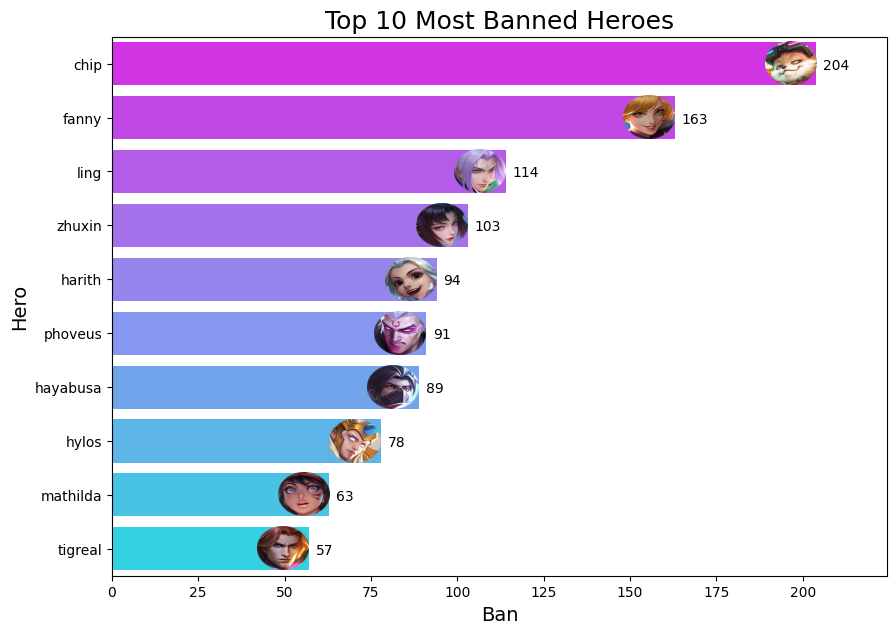

In [9]:
top_10_ban = df_hero_stats.sort_values('ban').tail(10).reset_index()


plt.figure(figsize=(10, 7))
ax = sns.barplot(top_10_ban, x='ban', y='hero', hue='hero', palette='cool')
for i, row in top_10_ban.iterrows():
  ax.text(row['ban']+2, i-.1, int(row['ban']))
  img = plt.imread(f"../hero_images/{row['hero']}.png")
  plt.imshow(img, extent=[row['ban']-15, row['ban'], i-0.4, i+0.4], aspect='auto', zorder=2)

plt.title("Top 10 Most Banned Heroes", fontsize=18)
plt.xlim(0, max(top_10_ban['ban']) * 1.1)
plt.ylim(-0.5, len(top_10_ban['hero']) - 0.5)
plt.xlabel('Ban', fontsize=14)
plt.ylabel('Hero', fontsize=14)
plt.show()

### Top 10 Most Picked Heroes

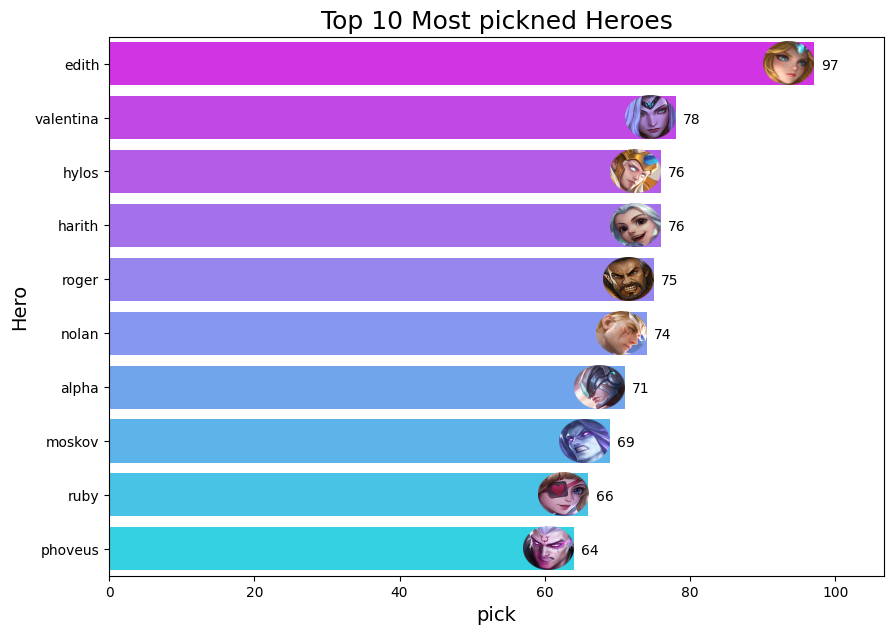

In [10]:
top_10_pick = df_hero_stats.sort_values('pick').tail(10).reset_index()

plt.figure(figsize=(10, 7))
ax = sns.barplot(top_10_pick, x='pick', y='hero', hue='hero', palette='cool')
for i, row in top_10_pick.iterrows():
  ax.text(row['pick']+1, i-0.1, int(row['pick']))
  img = plt.imread(f"../hero_images/{row['hero']}.png")
  plt.imshow(img, extent=[row['pick']-7, row['pick'], i-0.4, i+0.4], aspect='auto', zorder=2)

plt.title("Top 10 Most pickned Heroes", fontsize=18)
plt.xlim(0, max(top_10_pick['pick']) * 1.1)
plt.ylim(-0.5, len(top_10_pick['hero']) - 0.5)
plt.xlabel('pick', fontsize=14)
plt.ylabel('Hero', fontsize=14)
plt.show()

### Patch Version VS Total Game

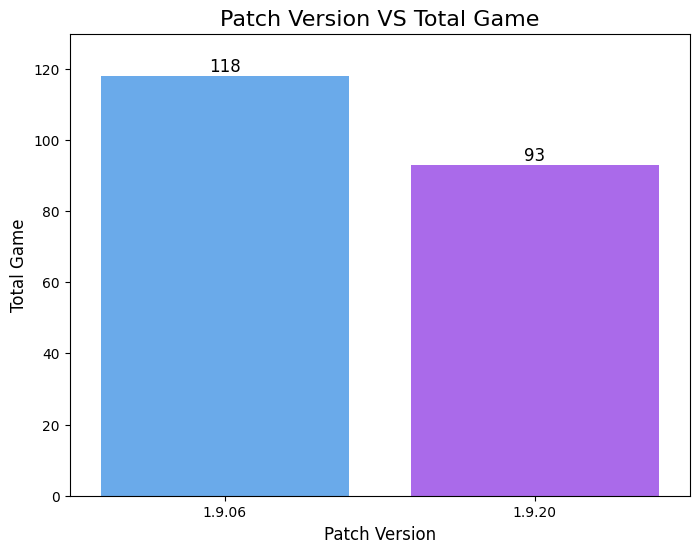

In [11]:
patch_vs_game = df_game_information.groupby('patch_version')['game_id'].agg(game='count')

plt.figure(figsize=(8,6))
ax = sns.barplot(patch_vs_game, x='patch_version', y='game', hue='patch_version', palette='cool')
for container in ax.containers:
  ax.bar_label(container, fontsize=12)
plt.title("Patch Version VS Total Game", fontsize=16)
plt.xlabel("Patch Version", fontsize=12)
plt.ylabel("Total Game", fontsize=12)
plt.ylim(0, max(patch_vs_game['game'] * 1.1))
plt.show()

### Top 10 Heroes Ban Rate by Patch Version

In [12]:
df_ban_information = df_game_information.merge(df_ban_heroes, on='game_id')
ban_patch_06 = []
ban_patch_20 = []

for i, row in df_ban_information.iterrows():
  for i in range(1, 6):
    if row['patch_version'] == '1.9.06':
      ban_patch_06.append(row[f'team_1_ban_{i}'])
      ban_patch_06.append(row[f'team_2_ban_{i}'])
    else:
      ban_patch_20.append(row[f'team_1_ban_{i}'])
      ban_patch_20.append(row[f'team_2_ban_{i}'])

total_games_patch_06 = patch_vs_game['game'].iloc[0]
df_ban_patch_06 = pd.DataFrame(ban_patch_06, columns=['hero'])
df_ban_patch_06 = df_ban_patch_06.value_counts().reset_index(name='ban')
df_ban_patch_06['banrate'] = (df_ban_patch_06['ban'] / total_games_patch_06) * 100
df_ban_patch_06['banrate'] = df_ban_patch_06['banrate'].round(2)
df_ban_patch_06


,hero,ban,banrate
0,chip,116,98.31
1,zhuxin,88,74.58
2,fanny,88,74.58
3,ling,85,72.03
4,hylos,64,54.24
...,...,...,...
56,bruno,1,0.85
57,gloo,1,0.85
58,hanabi,1,0.85
59,lancelot,1,0.85


In [13]:
total_games_patch_20 = patch_vs_game['game'].iloc[1]
df_ban_patch_20 = pd.DataFrame(ban_patch_20, columns=['hero'])
df_ban_patch_20 = df_ban_patch_20.value_counts().reset_index(name='ban')
df_ban_patch_20['banrate'] = (df_ban_patch_20['ban'] / total_games_patch_20) * 100
df_ban_patch_20['banrate'] = df_ban_patch_20['banrate'].round(2)
df_ban_patch_20

,hero,ban,banrate
0,chip,88,94.62
1,fanny,75,80.65
2,phoveus,65,69.89
3,mathilda,43,46.24
4,harith,41,44.09
...,...,...,...
56,lolita,1,1.08
57,lylia,1,1.08
58,jawhead,1,1.08
59,joy,1,1.08


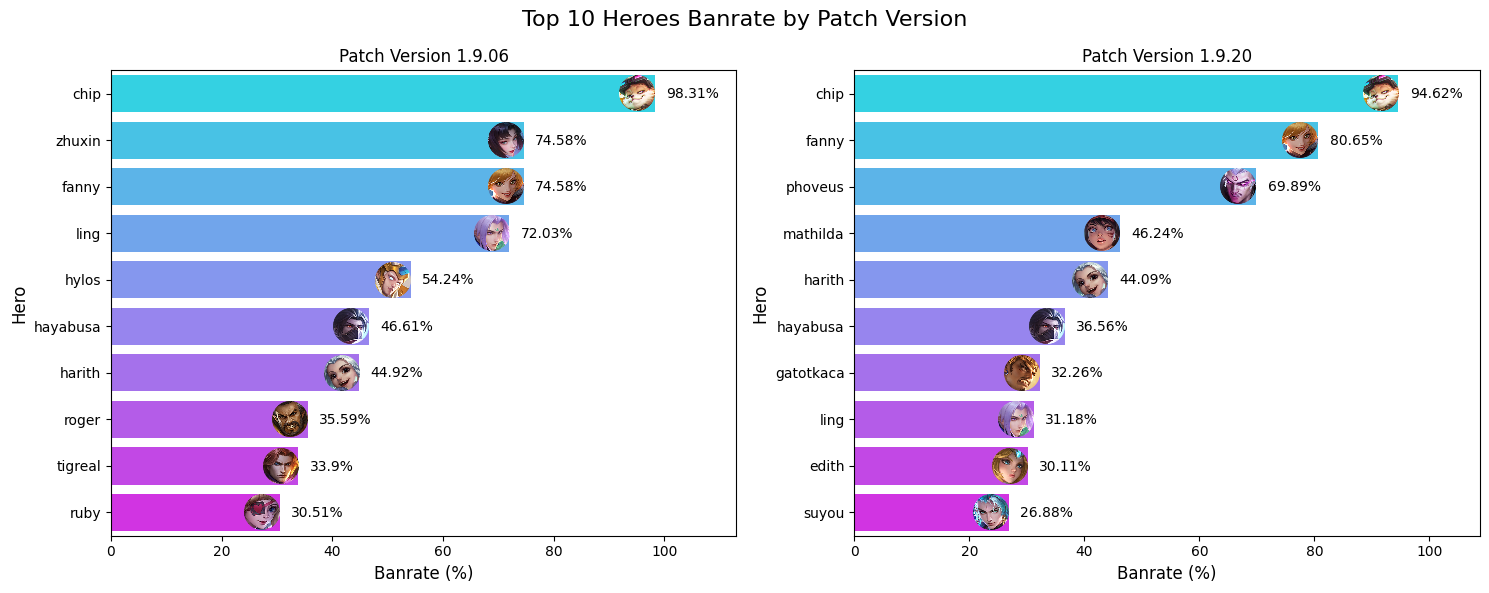

In [14]:
top_10_banrate_06 = df_ban_patch_06.sort_values('banrate', ascending=False).head(10).reset_index()
top_10_banrate_20 = df_ban_patch_20.sort_values('banrate', ascending=False).head(10).reset_index()

plt.figure(figsize=(15, 6))
plt.suptitle("Top 10 Heroes Banrate by Patch Version", fontsize=16)
# left plot
plt.subplot(1, 2, 1)
ax1 = sns.barplot(top_10_banrate_06, x='banrate', y='hero', hue='hero', palette='cool')
for i, row in top_10_banrate_06.iterrows():
  ax1.text(row['banrate']+2, i+0.1, f'{row["banrate"]}%')
  img = plt.imread(f"../hero_images/{row['hero']}.png")
  im = OffsetImage(img, zoom=0.2)
  im.image.axes = ax1
  ab = AnnotationBbox(im, (row['banrate'], i), xybox=(-13, 0), frameon=False, xycoords='data', boxcoords="offset points", pad=0)
  ax1.add_artist(ab)

ax1.set_title("Patch Version 1.9.06")
plt.xlim(0, max(top_10_banrate_06['banrate']) * 1.15)
plt.xlabel('Banrate (%)', fontsize=12)
plt.ylabel('Hero', fontsize=12)
# right plot
plt.subplot(1, 2, 2)
ax2 = sns.barplot(top_10_banrate_20, x='banrate', y='hero', hue='hero', palette='cool')
for i, row in top_10_banrate_20.iterrows():
  ax2.text(row['banrate']+2, i+0.1, f'{row["banrate"]}%')
  img = plt.imread(f"../hero_images/{row['hero']}.png")
  im = OffsetImage(img, zoom=0.2)
  im.image.axes = ax2
  ab = AnnotationBbox(im, (row['banrate'], i), xybox=(-13, 0), frameon=False, xycoords='data', boxcoords="offset points", pad=0)
  ax2.add_artist(ab)
ax2.set_title("Patch Version 1.9.20")
plt.xlim(0, max(top_10_banrate_20['banrate']) * 1.15)
plt.xlabel('Banrate (%)', fontsize=12)
plt.ylabel('Hero', fontsize=12)

plt.tight_layout()
plt.show()

### Top 10 Heroes Pick Rate by Patch Version

In [15]:
df_pick_information = df_game_information.merge(df_pick_heroes, on='game_id')
pick_patch_06 = []
pick_patch_20 = []

for i, row in df_pick_information.iterrows():
  for i in range(1, 6):
    if row['patch_version'] == '1.9.06':
      pick_patch_06.append(row[f'team_1_pick_{i}'])
      pick_patch_06.append(row[f'team_2_pick_{i}'])
    else:
      pick_patch_20.append(row[f'team_1_pick_{i}'])
      pick_patch_20.append(row[f'team_2_pick_{i}'])

df_pick_patch_06 = pd.DataFrame(pick_patch_06, columns=['hero'])
df_pick_patch_06 = df_pick_patch_06.value_counts().reset_index(name='pick')
df_pick_patch_06['pickrate'] = (df_pick_patch_06['pick'] / total_games_patch_06) * 100
df_pick_patch_06['pickrate'] = df_pick_patch_06['pickrate'].round(2)
df_pick_patch_06

,hero,pick,pickrate
0,roger,68,57.63
1,edith,68,57.63
2,zhask,51,43.22
3,moskov,51,43.22
4,harith,50,42.37
...,...,...,...
66,minsitthar,1,0.85
67,masha,1,0.85
68,helcurt,1,0.85
69,ixia,1,0.85


In [16]:
df_pick_patch_20 = pd.DataFrame(pick_patch_20, columns=['hero'])
df_pick_patch_20 = df_pick_patch_20.value_counts().reset_index(name='pick')
df_pick_patch_20['pickrate'] = (df_pick_patch_20['pick'] / total_games_patch_20) * 100
df_pick_patch_20['pickrate'] = df_pick_patch_20['pickrate'].round(2)
df_pick_patch_20

,hero,pick,pickrate
0,alpha,44,47.31
1,yve,41,44.09
2,hylos,37,39.78
3,gatotkaca,37,39.78
4,khaleed,36,38.71
...,...,...,...
65,martis,1,1.08
66,helcurt,1,1.08
67,yu zhong,1,1.08
68,atlas,1,1.08


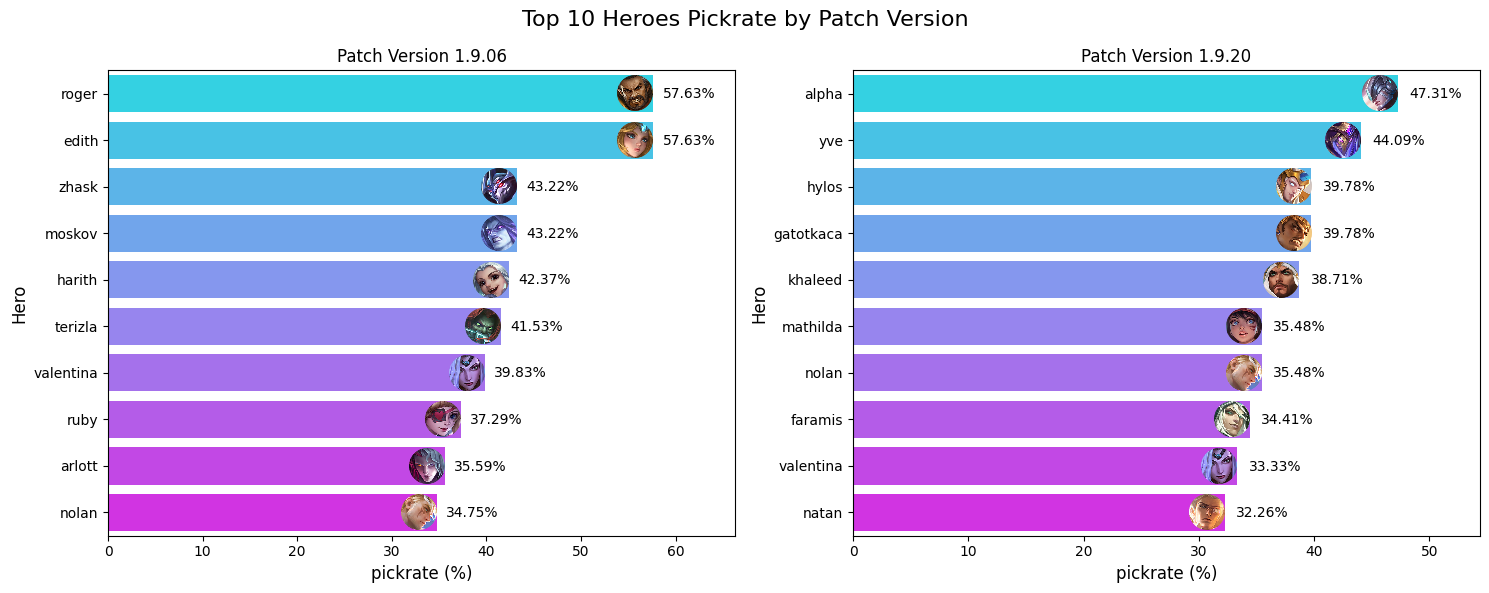

In [17]:
top_10_pickrate_06 = df_pick_patch_06.sort_values('pickrate', ascending=False).head(10).reset_index()
top_10_pickrate_20 = df_pick_patch_20.sort_values('pickrate', ascending=False).head(10).reset_index()

plt.figure(figsize=(15, 6))
plt.suptitle("Top 10 Heroes Pickrate by Patch Version", fontsize=16)
# left plot
plt.subplot(1, 2, 1)
ax1 = sns.barplot(top_10_pickrate_06, x='pickrate', y='hero', hue='hero', palette='cool')
for i, row in top_10_pickrate_06.iterrows():
  ax1.text(row['pickrate']+1, i+0.1, f'{row["pickrate"]}%')
  img = plt.imread(f"../hero_images/{row['hero']}.png")
  im = OffsetImage(img, zoom=0.2)
  im.image.axes = ax1
  ab = AnnotationBbox(im, (row['pickrate'], i), xybox=(-13, 0), frameon=False, xycoords='data', boxcoords="offset points", pad=0)
  ax1.add_artist(ab)

ax1.set_title("Patch Version 1.9.06")
plt.xlim(0, max(top_10_pickrate_06['pickrate']) * 1.15)
plt.xlabel('pickrate (%)', fontsize=12)
plt.ylabel('Hero', fontsize=12)
# right plot
plt.subplot(1, 2, 2)
ax2 = sns.barplot(top_10_pickrate_20, x='pickrate', y='hero', hue='hero', palette='cool')
for i, row in top_10_pickrate_20.iterrows():
  ax2.text(row['pickrate']+1, i+0.1, f'{row["pickrate"]}%')
  img = plt.imread(f"../hero_images/{row['hero']}.png")
  im = OffsetImage(img, zoom=0.2)
  im.image.axes = ax2
  ab = AnnotationBbox(im, (row['pickrate'], i), xybox=(-13, 0), frameon=False, xycoords='data', boxcoords="offset points", pad=0)
  ax2.add_artist(ab)
ax2.set_title("Patch Version 1.9.20")
plt.xlim(0, max(top_10_pickrate_20['pickrate']) * 1.15)
plt.xlabel('pickrate (%)', fontsize=12)
plt.ylabel('Hero', fontsize=12)

plt.tight_layout()
plt.show()

### Hero Distribution per Draft Steps by Patch Version

In [71]:
df_steps = df_game_information.merge(df_ban_heroes, on='game_id')
df_steps = df_steps.merge(df_pick_heroes, on='game_id')
df_steps = df_steps.rename(columns={
  'team_1_ban_1': 'step_1', 'team_2_ban_1': 'step_2', 'team_1_ban_2': 'step_3', 'team_2_ban_2': 'step_4',
  'team_1_ban_3': 'step_5', 'team_2_ban_3': 'step_6', 'team_1_pick_1': 'step_7', 'team_2_pick_1': 'step_8',
  'team_2_pick_2': 'step_9', 'team_1_pick_2': 'step_10', 'team_1_pick_3': 'step_11', 'team_2_pick_3': 'step_12',
  'team_2_ban_4': 'step_13', 'team_1_ban_4': 'step_14', 'team_2_ban_5': 'step_15', 'team_1_ban_5': 'step_16',
  'team_2_pick_4': 'step_17', 'team_1_pick_4': 'step_18', 'team_1_pick_5': 'step_19', 'team_2_pick_5': 'step_20'
})

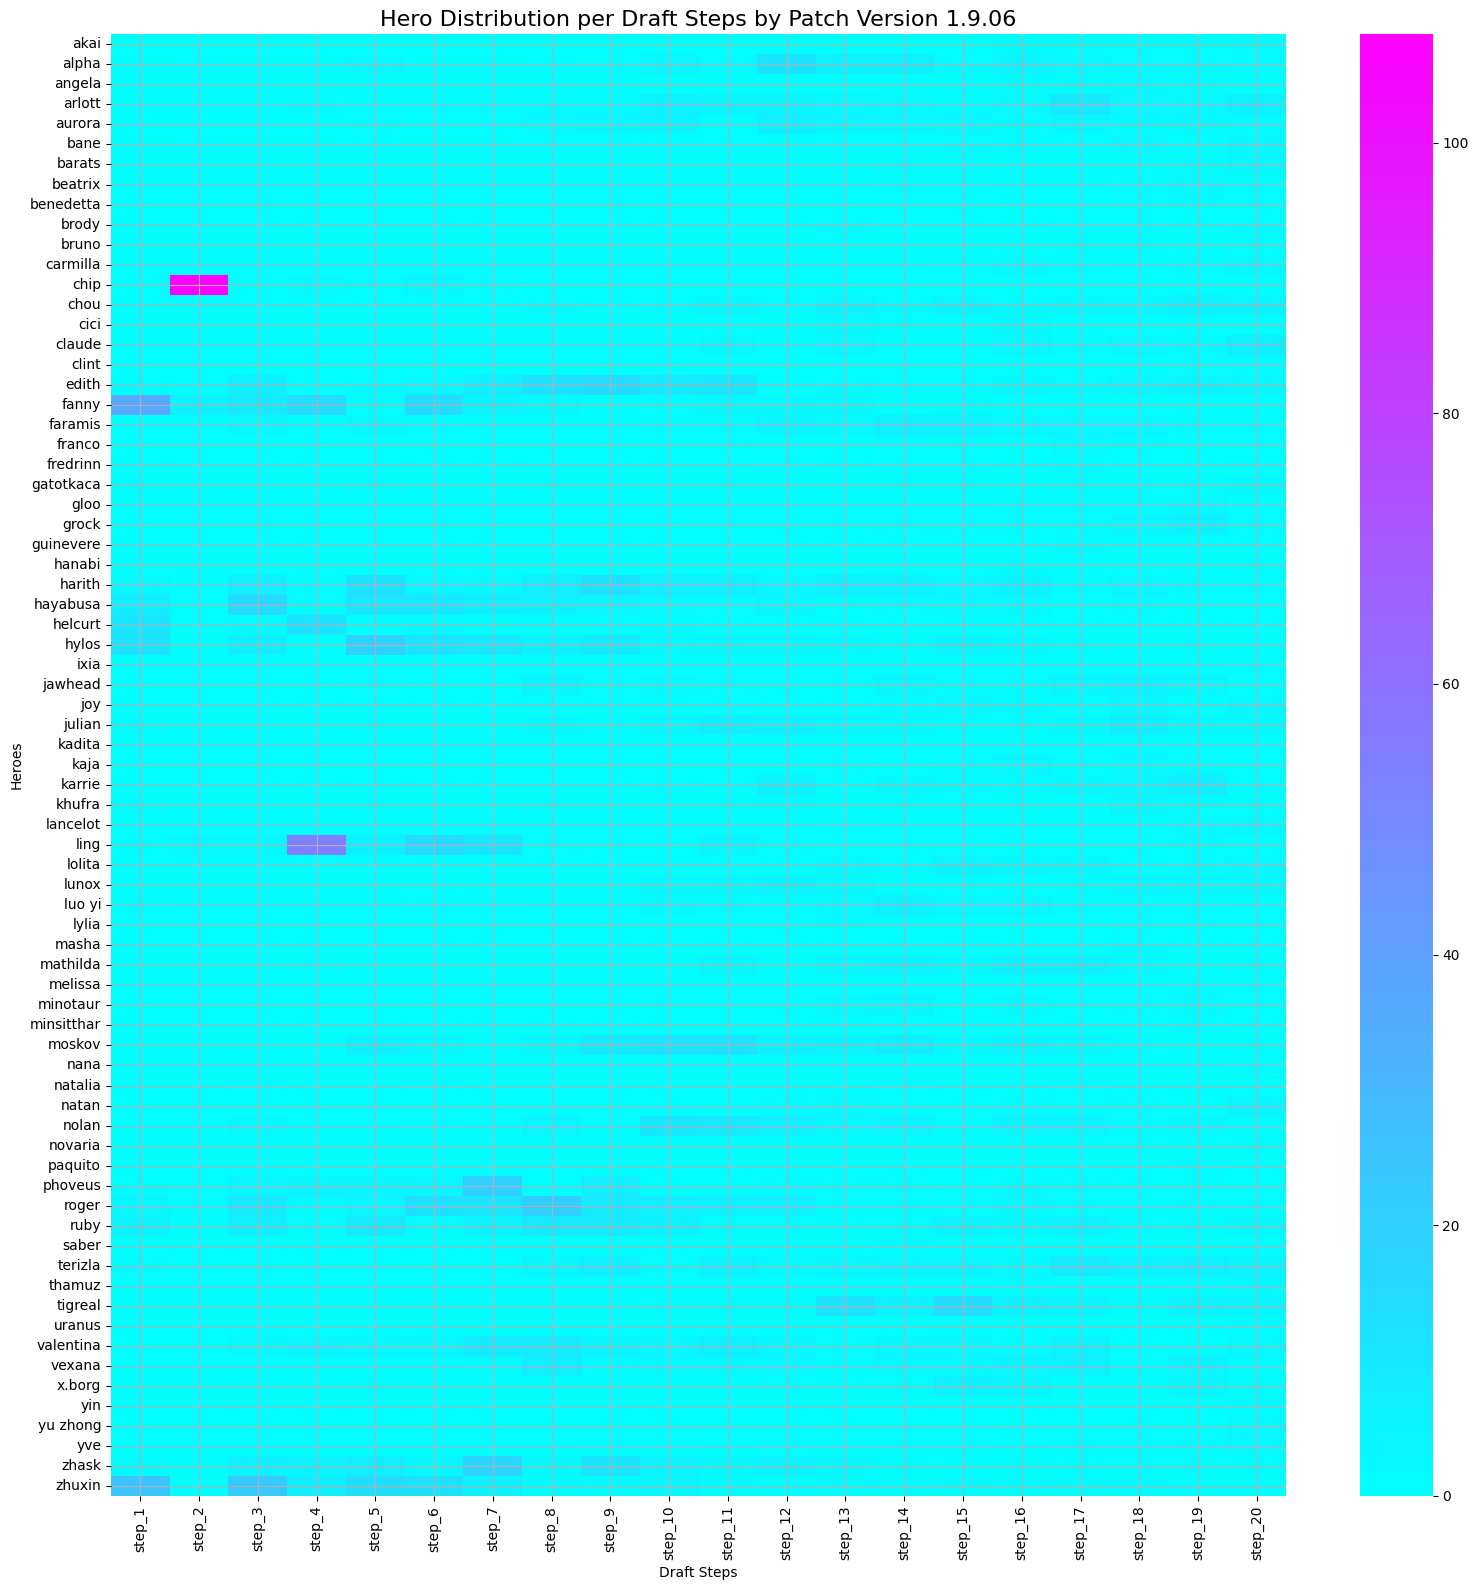

In [77]:
df_steps_06 = df_steps[df_steps['patch_version'] == '1.9.06'][['step_1', 'step_2', 'step_3', 'step_4', 'step_5',
                      'step_6', 'step_7', 'step_8', 'step_9', 'step_10', 'step_11', 'step_12', 'step_13', 'step_14',
                      'step_15', 'step_16', 'step_17', 'step_18', 'step_19', 'step_20']]
df_steps_06

df_long_06 = df_steps_06.melt(var_name='step', value_name='hero')
step_counts_06 = df_long_06.value_counts(['hero', 'step']).reset_index(name='count')
df_pivot_06 = step_counts_06.pivot(index='hero', columns='step', values='count').fillna(0)
df_pivot_06 = df_pivot_06[['step_1', 'step_2', 'step_3', 'step_4', 'step_5', 'step_6', 'step_7', 'step_8', 'step_9', 'step_10',
                     'step_11', 'step_12', 'step_13', 'step_14', 'step_15', 'step_16', 'step_17', 'step_18', 'step_19', 'step_20']]

plt.figure(figsize=(16, 16))
sns.heatmap(df_pivot_06, cmap='cool')
plt.title('Hero Distribution per Draft Steps by Patch Version 1.9.06', fontsize=16)
plt.xlabel('Draft Steps')
plt.ylabel('Heroes')
plt.tight_layout()
plt.grid(True)
plt.show()

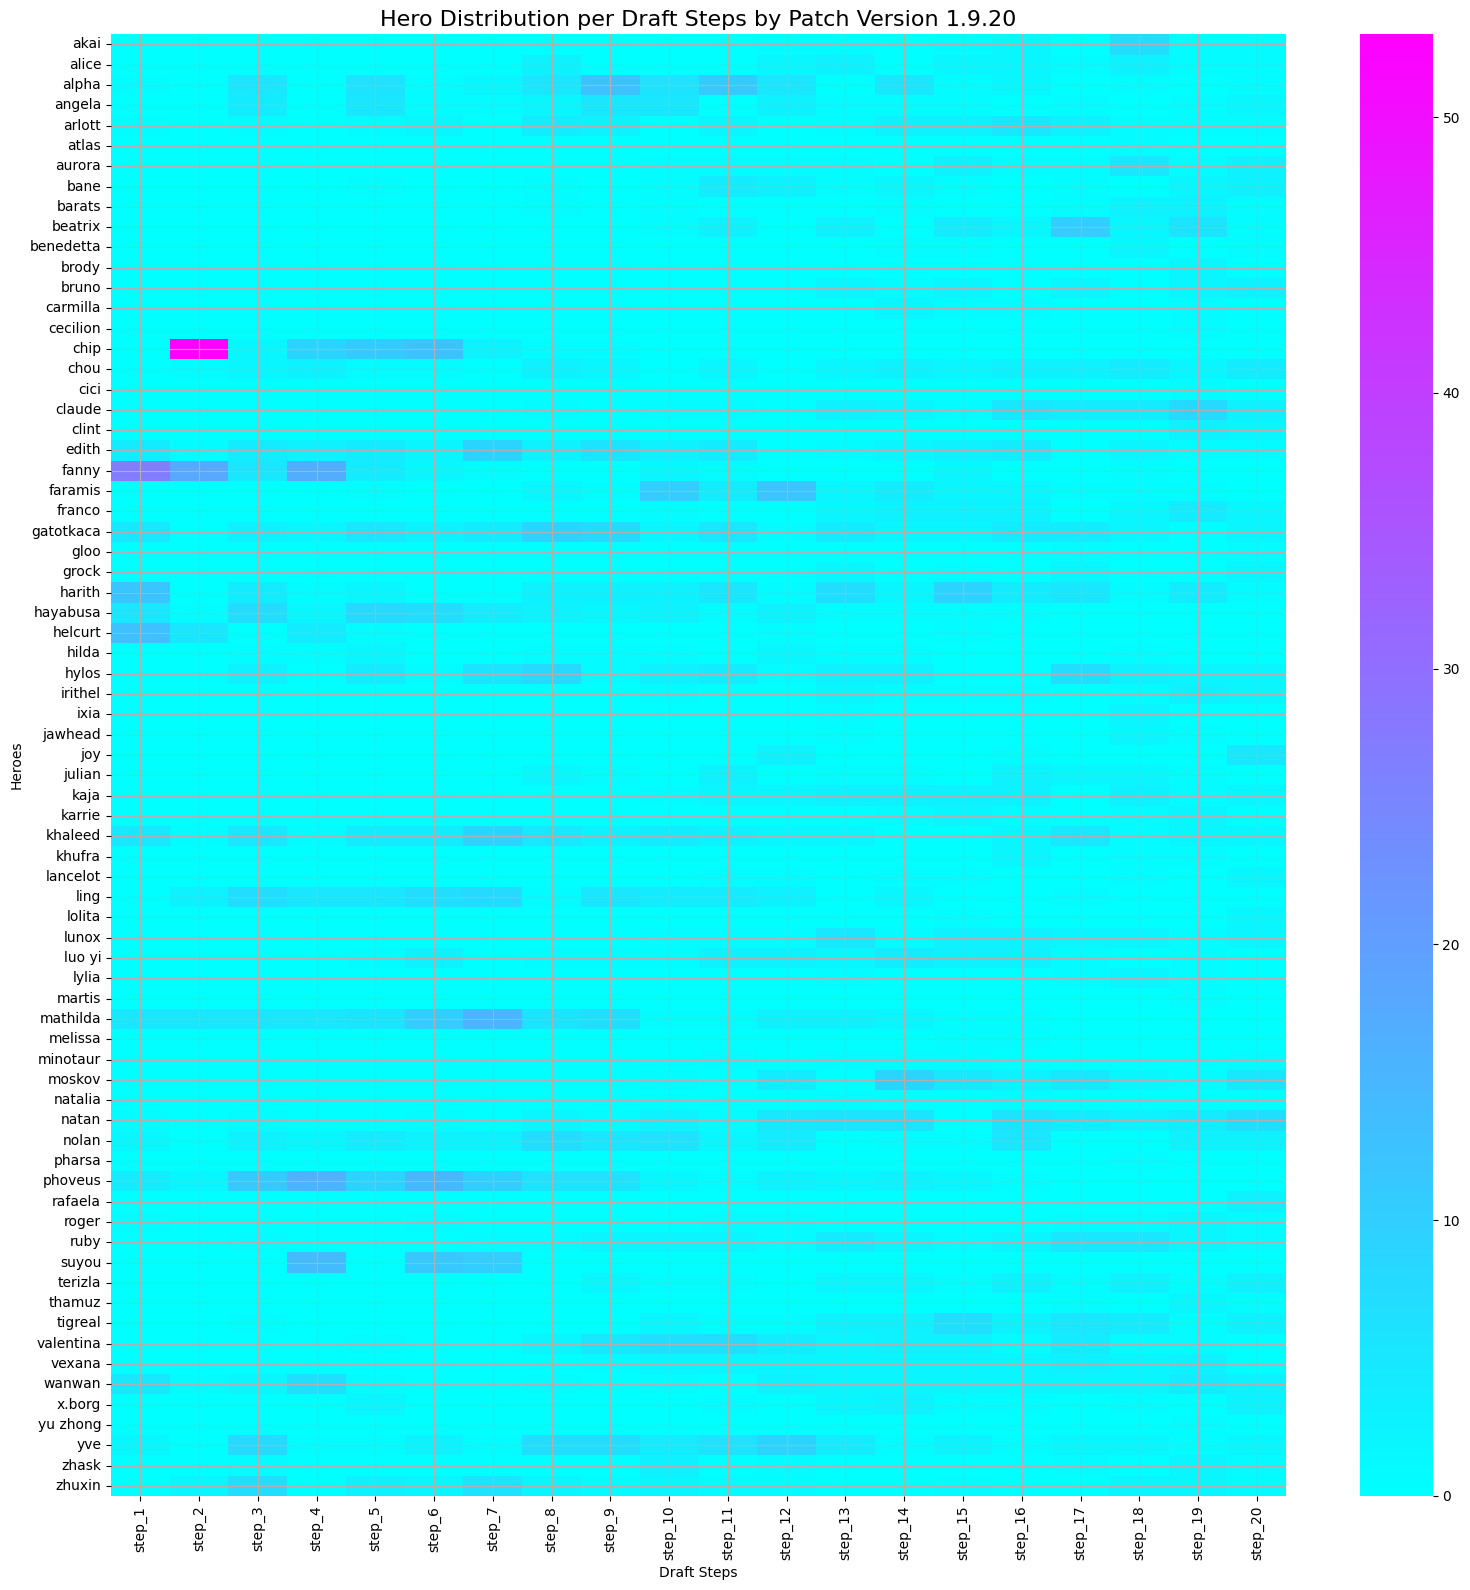

In [78]:
df_steps_20 = df_steps[df_steps['patch_version'] == '1.9.20'][['step_1', 'step_2', 'step_3', 'step_4', 'step_5',
                      'step_6', 'step_7', 'step_8', 'step_9', 'step_10', 'step_11', 'step_12', 'step_13', 'step_14',
                      'step_15', 'step_16', 'step_17', 'step_18', 'step_19', 'step_20']]

df_long_20 = df_steps_20.melt(var_name='step', value_name='hero')
step_counts_20 = df_long_20.value_counts(['hero', 'step']).reset_index(name='count')
df_pivot_20 = step_counts_20.pivot(index='hero', columns='step', values='count').fillna(0)
df_pivot_20 = df_pivot_20[['step_1', 'step_2', 'step_3', 'step_4', 'step_5', 'step_6', 'step_7', 'step_8', 'step_9', 'step_10',
                     'step_11', 'step_12', 'step_13', 'step_14', 'step_15', 'step_16', 'step_17', 'step_18', 'step_19', 'step_20']]

plt.figure(figsize=(16, 16))
sns.heatmap(df_pivot_20, cmap='cool')
plt.title('Hero Distribution per Draft Steps by Patch Version 1.9.20', fontsize=16)
plt.xlabel('Draft Steps')
plt.ylabel('Heroes')
plt.tight_layout()
plt.grid(True)
plt.show()